# 🤖 NLP03 — 더 멋진 번역기 만들기 (Transformer)

> **모두연 엔지니어 3기 · AIFFEL Quest ENG · NLP03**  
> Transformer 구조를 처음부터 직접 구현하고, 한-영 번역기를 완성합니다.

---

## 📋 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **목표** | Transformer 모델로 한→영 번역기 구현 |
| **데이터** | 한영 병렬 말뭉치 (korean-english-park) |
| **토크나이저** | SentencePiece (BPE) |
| **프레임워크** | PyTorch |
| **평가** | 번역 품질 + Attention Map 시각화 |

---

## 🗺️ 전체 진행 과정

```
Step 1. 라이브러리 설치 및 환경 설정
Step 2. 데이터 다운로드
Step 3. 데이터 정제 및 토큰화 (SentencePiece)
Step 4. 내부 모듈 구현
         ├─ Positional Encoding
         ├─ Multi-Head Attention
         └─ Position-wise FFN
Step 5. 모듈 조립
         ├─ EncoderLayer / DecoderLayer
         ├─ Encoder / Decoder
         └─ Transformer
Step 6. 모델 밖의 조력자들
         ├─ Masking (Padding + Causality)
         └─ Learning Rate Scheduler
Step 7. 학습
Step 8. 번역 & Attention Map 시각화
```

---

## ⚙️ Step 1. 라이브러리 설치 및 환경 설정

- `sentencepiece`: 한/영 서브워드 토크나이저
- `matplotlib` 한글 폰트 설정 (Attention Map 시각화용)

In [26]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [1]:
# ── 필수 라이브러리 설치 ──────────────────────────────────────────
!pip install sentencepiece -q

# 한글 폰트 설치 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# NanumGothic 폰트 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
matplotlib.rcParams['font.family'] = font_prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

print('✅ 폰트 설정 완료:'  , font_prop.get_name())

✅ 폰트 설정 완료: NanumGothic


In [2]:
# ── 공통 import ──────────────────────────────────────────────────
import os
import re
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 재현성
torch.manual_seed(42)
np.random.seed(42)

# GPU 확인
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ 사용 디바이스:', DEVICE)

# 라이브러리 버전 확인
print('PyTorch :', torch.__version__)
print('SentencePiece :', spm.__version__)

✅ 사용 디바이스: cuda
PyTorch : 2.11.0+cu128
SentencePiece : 0.2.1


---

## 📥 Step 2. 데이터 다운로드

- 한영 병렬 말뭉치 `korean-english-park.train` 다운로드
- 출처: [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora)

In [3]:
# ── 데이터 다운로드 ───────────────────────────────────────────────
import os

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

# 한영 병렬 말뭉치 다운로드
!wget -q https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz \
    -O {DATA_DIR}/korean-english-park.train.tar.gz

!gzip -d {DATA_DIR}/korean-english-park.train.tar.gz
!tar -xvf {DATA_DIR}/korean-english-park.train.tar -C {DATA_DIR}

# 파일 확인
!ls -lh {DATA_DIR}/

KO_FILE = f'{DATA_DIR}/korean-english-park.train.ko'
EN_FILE = f'{DATA_DIR}/korean-english-park.train.en'

# 데이터 미리보기
with open(KO_FILE) as f:
    ko_lines = f.readlines()
with open(EN_FILE) as f:
    en_lines = f.readlines()

print(f'\n총 데이터 수: {len(ko_lines):,}개')
print('\n[한국어 예시]')
for line in ko_lines[:3]:
    print(' ', line.strip())
print('\n[영어 예시]')
for line in en_lines[:3]:
    print(' ', line.strip())

korean-english-park.train.en
korean-english-park.train.ko
total 50M
-rw-r--r-- 1  501 staff 12M Jul 12  2014 korean-english-park.train.en
-rw-r--r-- 1  501 staff 14M Jul 12  2014 korean-english-park.train.ko
-rw-r--r-- 1 root root  25M Jul 13 00:47 korean-english-park.train.tar

총 데이터 수: 94,123개

[한국어 예시]
  개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
  모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
  그러나 이것은 또한 책상도 필요로 하지 않는다.

[영어 예시]
  Much of personal computing is about "can you top this?"
  so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
  Like all optical mice, But it also doesn't need a desk.


---

## 🧹 Step 3. 데이터 정제 및 토큰화

### 3-1. 중복 제거 & 정제
- `set` 자료형으로 완전 중복 쌍 제거
- 소문자 변환, 알파벳/한글/문장부호만 남기기
- 문장부호 양옆 공백 추가

### 3-2. SentencePiece 토크나이저
- 한/영 각각 vocab_size=20,000으로 학습
- 특수 토큰: `<PAD>=0`, `<BOS>=1`, `<EOS>=2`, `<UNK>=3`
- 영어 타겟에 `set_encode_extra_options("bos:eos")` 적용

### 3-3. 텐서 변환
- 토큰 길이 50 이하 데이터만 선별
- `enc_train`, `dec_train` 텐서로 변환

In [4]:
# ── 3-1. 중복 제거 & 정제 함수 정의 ─────────────────────────────

def preprocess(sentence):
    """정제 함수: 소문자 변환, 알파벳/한글/문장부호만 남김, 문장부호 양옆 공백 추가"""
    sentence = sentence.lower().strip()
    # 알파벳, 한글, 기본 문장부호만 남기기
    sentence = re.sub(r"[^a-z가-힣?.!,\s]+", " ", sentence)
    # 문장부호 양옆 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 연속 공백 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 중복 제거 (완전 동일한 (한, 영) 쌍만 제거)
seen = set()
cleaned_corpus = []
for ko, en in zip(ko_lines, en_lines):
    ko_p, en_p = preprocess(ko), preprocess(en)
    key = (ko_p, en_p)
    if key not in seen and ko_p and en_p:
        seen.add(key)
        cleaned_corpus.append((ko_p, en_p))

print(f'원본: {len(ko_lines):,}개  →  중복 제거 후: {len(cleaned_corpus):,}개')
print('\n예시:')
for ko, en in cleaned_corpus[:3]:
    print(f'  KO: {ko}')
    print(f'  EN: {en}')
    print()

원본: 94,123개  →  중복 제거 후: 78,833개

예시:
  KO: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  EN: much of personal computing is about can you top this ?

  KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
  EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .

  KO: 그러나 이것은 또한 책상도 필요로 하지 않는다 .
  EN: like all optical mice , but it also doesn t need a desk .



In [5]:
# ── 3-2. SentencePiece 토크나이저 학습 ───────────────────────────
import sentencepiece as spm

# 학습용 임시 파일 저장
KO_CORPUS = f'{DATA_DIR}/ko_corpus.txt'
EN_CORPUS = f'{DATA_DIR}/en_corpus.txt'

with open(KO_CORPUS, 'w') as f:
    for ko, _ in cleaned_corpus:
        f.write(ko + '\n')

with open(EN_CORPUS, 'w') as f:
    for _, en in cleaned_corpus:
        f.write(en + '\n')

VOCAB_SIZE = 20000

def generate_tokenizer(input_file, prefix, vocab_size=VOCAB_SIZE):
    """SentencePiece 토크나이저 학습 및 로드"""
    spm.SentencePieceTrainer.train(
        input=input_file,
        model_prefix=prefix,
        vocab_size=vocab_size,
        pad_id=0,    # <PAD>
        bos_id=1,    # <BOS>
        eos_id=2,    # <EOS>
        unk_id=3,    # <UNK>
        model_type='bpe',
        character_coverage=1.0
    )
    sp = spm.SentencePieceProcessor()
    sp.Load(f'{prefix}.model')
    return sp

# 한/영 토크나이저 각각 학습
print('🔧 한국어 토크나이저 학습 중...')
ko_tokenizer = generate_tokenizer(KO_CORPUS, f'{DATA_DIR}/ko_spm')

print('🔧 영어 토크나이저 학습 중...')
en_tokenizer = generate_tokenizer(EN_CORPUS, f'{DATA_DIR}/en_spm')

# 영어 타겟: BOS/EOS 자동 추가
en_tokenizer.set_encode_extra_options('bos:eos')

# 토크나이저 확인
test_ko = '오바마는 대통령이다 .'
test_en = 'obama is the president .'
print(f'\nKO 토크나이즈: {ko_tokenizer.encode(test_ko)}')
print(f'EN 토크나이즈: {en_tokenizer.encode(test_en)}')

🔧 한국어 토크나이저 학습 중...
🔧 영어 토크나이저 학습 중...

KO 토크나이즈: [1229, 79, 132, 4]
EN 토크나이즈: [1, 532, 81, 9, 230, 15, 2]


In [6]:
# ── 3-3. 텐서 변환 (토큰 길이 50 이하만 선별) ─────────────────────
from torch.nn.utils.rnn import pad_sequence

MAX_LEN = 50

src_corpus, tgt_corpus = [], []
for ko, en in cleaned_corpus:
    ko_tok = ko_tokenizer.encode(ko)
    en_tok = en_tokenizer.encode(en)
    if len(ko_tok) <= MAX_LEN and len(en_tok) <= MAX_LEN:
        src_corpus.append(torch.tensor(ko_tok, dtype=torch.long))
        tgt_corpus.append(torch.tensor(en_tok, dtype=torch.long))

# 패딩 (PAD_ID=0)
enc_train = pad_sequence(src_corpus, batch_first=True, padding_value=0)  # [N, src_len]
dec_train = pad_sequence(tgt_corpus, batch_first=True, padding_value=0)  # [N, tgt_len]

print(f'✅ 데이터 선별 완료')
print(f'   전체 → 선별: {len(cleaned_corpus):,} → {len(src_corpus):,}개')
print(f'   enc_train shape: {enc_train.shape}')
print(f'   dec_train shape: {dec_train.shape}')

✅ 데이터 선별 완료
   전체 → 선별: 78,833 → 75,362개
   enc_train shape: torch.Size([75362, 50])
   dec_train shape: torch.Size([75362, 50])


---

## 🧩 Step 4. 내부 모듈 구현

### 4-1. Positional Encoding
- 입력 임베딩에 위치 정보를 더해주는 모듈
- `sin/cos` 함수로 각 위치마다 고유한 패턴 생성
- 수식: `PE(pos, 2i) = sin(pos / 10000^(2i/d_model))`

### 4-2. Multi-Head Attention
- `split_heads()`: d_model → [batch, heads, length, depth]
- `scaled_dot_product_attention()`: Attention(Q, K, V) = softmax(QK^T / √d_k) · V
- `combine_heads()`: 분할된 Head 결합
- Masking 지원 (Padding / Causality)

### 4-3. Position-wise FFN
- Linear(d_model → d_ff) → ReLU → Linear(d_ff → d_model)

In [7]:
# ── 4-1. Positional Encoding ──────────────────────────────────────
# 역할: Transformer는 순서 정보가 없으므로 위치 정보를 임베딩에 더해줌
# sin/cos 함수로 각 위치마다 고유한 벡터 생성

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # PE 행렬 생성 [max_len x d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 차원: sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 차원: cos
        pe = pe.unsqueeze(0)  # [1, max_len, d_model] — 배치 차원 추가
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch, length, d_model]
        x = x + self.pe[:, :x.size(1), :]  # 위치 벡터 더하기
        return self.dropout(x)

# 동작 확인
pe_test = PositionalEncoding(d_model=512)
x_test  = torch.zeros(2, 10, 512)  # [batch=2, length=10, d_model=512]
out_test = pe_test(x_test)
print('✅ Positional Encoding 출력 shape:', out_test.shape)  # [2, 10, 512]

✅ Positional Encoding 출력 shape: torch.Size([2, 10, 512])


In [8]:
# ── 4-2. Multi-Head Attention ─────────────────────────────────────
# 역할: 여러 관점(head)으로 동시에 Attention 수행
#       Q(Query), K(Key), V(Value)로 단어 간 관계 파악
# 핵심: Attention(Q,K,V) = softmax(QK^T / √d_k) · V

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model은 n_heads로 나눠져야 합니다'
        self.d_model  = d_model
        self.n_heads  = n_heads
        self.depth    = d_model // n_heads  # 각 head의 차원

        # Q, K, V 선형 변환 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # 출력 선형 변환

    def split_heads(self, x, batch_size):
        """[batch, length, d_model] → [batch, heads, length, depth]"""
        x = x.view(batch_size, -1, self.n_heads, self.depth)
        return x.transpose(1, 2)  # [batch, heads, length, depth]

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Attention(Q, K, V) = softmax(QK^T / √d_k) · V"""
        # QK^T: 유사도 점수 계산 [batch, heads, q_len, k_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.depth)

        # 마스킹: PAD나 미래 토큰에 매우 작은 값(-1e9)을 더해 softmax 후 0에 가까워지게
        if mask is not None:
            scores = scores + (mask * -1e9)

        # Softmax → Attention 가중치
        attn_weights = F.softmax(scores, dim=-1)  # [batch, heads, q_len, k_len]

        # 가중합으로 최종 출력
        output = torch.matmul(attn_weights, V)  # [batch, heads, q_len, depth]
        return output, attn_weights

    def combine_heads(self, x, batch_size):
        """[batch, heads, length, depth] → [batch, length, d_model]"""
        x = x.transpose(1, 2).contiguous()  # [batch, length, heads, depth]
        return x.view(batch_size, -1, self.d_model)  # [batch, length, d_model]

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        # 선형 변환 후 head 분할
        Q = self.split_heads(self.W_q(Q), batch_size)  # [batch, heads, q_len, depth]
        K = self.split_heads(self.W_k(K), batch_size)  # [batch, heads, k_len, depth]
        V = self.split_heads(self.W_v(V), batch_size)  # [batch, heads, v_len, depth]

        # Scaled Dot-Product Attention
        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Head 결합 후 출력 선형 변환
        output = self.W_o(self.combine_heads(attn_output, batch_size))  # [batch, length, d_model]
        return output, attn_weights

# 동작 확인
mha_test = MultiHeadAttention(d_model=512, n_heads=8)
q = k = v = torch.zeros(2, 10, 512)  # [batch=2, length=10, d_model=512]
out, attn = mha_test(q, k, v)
print('✅ MHA 출력 shape:', out.shape)       # [2, 10, 512]
print('✅ Attention 가중치 shape:', attn.shape)  # [2, 8, 10, 10]

✅ MHA 출력 shape: torch.Size([2, 10, 512])
✅ Attention 가중치 shape: torch.Size([2, 8, 10, 10])


In [9]:
# ── 4-3. Position-wise Feed-Forward Network ───────────────────────
# 역할: Attention이 단어 관계를 파악했다면, FFN은 의미를 변환
#       Linear(d_model → d_ff) → ReLU → Linear(d_ff → d_model)
#       논문: d_model=512, d_ff=2048 (4배 확장 후 압축)

class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1    = nn.Linear(d_model, d_ff)   # 확장: 512 → 2048
        self.w_2    = nn.Linear(d_ff, d_model)   # 압축: 2048 → 512
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch, length, d_model]
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

# 동작 확인
ffn_test = PositionwiseFFN(d_model=512, d_ff=2048)
x_test   = torch.zeros(2, 10, 512)
print('✅ FFN 출력 shape:', ffn_test(x_test).shape)  # [2, 10, 512]

✅ FFN 출력 shape: torch.Size([2, 10, 512])


---

## 🏗️ Step 5. 모듈 조립하기

### 5-1. EncoderLayer
- Self-Attention → Add & Norm → FFN → Add & Norm
- **Pre-LN** 구조: Norm이 서브레이어 입력 앞에 위치 (논문 Official 구현)

### 5-2. DecoderLayer  
- Masked Self-Attention → Add & Norm
- Cross-Attention (Q=디코더, K/V=인코더) → Add & Norm
- FFN → Add & Norm

### 5-3. Encoder / Decoder / Transformer
- N개의 레이어를 동적으로 쌓아 실험 가능
- `shared=True` 시 Decoder Embedding과 출력층 Weight 공유

In [10]:
# ── 5-1. EncoderLayer ─────────────────────────────────────────────
# Pre-LN 구조: [Input] → [Norm] → [MHA] → [Residual] → [Norm] → [FFN] → [Residual]
# 논문 Official 구현 방식 (레이어 많을수록 Pre-LN이 유리)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads)  # Self-Attention
        self.ffn        = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model, eps=1e-6)       # Attention 앞 Norm
        self.norm2      = nn.LayerNorm(d_model, eps=1e-6)       # FFN 앞 Norm
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, src_mask=None):
        # Pre-LN Self-Attention (Q=K=V=x, 자기 자신 참조)
        normed = self.norm1(x)
        attn_out, enc_attn = self.self_attn(normed, normed, normed, src_mask)
        x = x + self.dropout(attn_out)   # Residual Connection

        # Pre-LN FFN
        normed = self.norm2(x)
        ffn_out = self.ffn(normed)
        x = x + self.dropout(ffn_out)    # Residual Connection
        return x, enc_attn

print('✅ EncoderLayer 정의 완료')

✅ EncoderLayer 정의 완료


In [11]:
# ── 5-2. DecoderLayer ─────────────────────────────────────────────
# Encoder와 달리 Attention이 두 번 진행:
#   ① Masked Self-Attention: 미래 토큰 참조 방지 (인과 관계 마스크)
#   ② Cross-Attention: Q=디코더, K/V=인코더 출력 (번역 참조)

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn   = MultiHeadAttention(d_model, n_heads)  # Masked Self-Attention
        self.cross_attn  = MultiHeadAttention(d_model, n_heads)  # Cross-Attention
        self.ffn         = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1       = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2       = nn.LayerNorm(d_model, eps=1e-6)
        self.norm3       = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask=None, src_mask=None):
        # ① Masked Self-Attention (디코더가 자기 자신의 이전 출력만 참조)
        normed = self.norm1(x)
        self_attn_out, dec_attn = self.self_attn(normed, normed, normed, tgt_mask)
        x = x + self.dropout(self_attn_out)

        # ② Cross-Attention (Q=디코더, K/V=인코더 출력)
        normed = self.norm2(x)
        cross_attn_out, dec_enc_attn = self.cross_attn(normed, enc_out, enc_out, src_mask)
        x = x + self.dropout(cross_attn_out)

        # FFN
        normed = self.norm3(x)
        ffn_out = self.ffn(normed)
        x = x + self.dropout(ffn_out)

        return x, dec_attn, dec_enc_attn  # Attention 두 개 반환

print('✅ DecoderLayer 정의 완료')

✅ DecoderLayer 정의 완료


In [12]:
# ── 5-3. Encoder ──────────────────────────────────────────────────
# N개의 EncoderLayer를 동적으로 쌓음
# 스택 끝에 final_norm 추가 (Pre-LN 표준 구조 — residual 누적 방지)

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_layers   = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        # Pre-LN 표준: 스택 마지막 출력 정규화
        # (누락 시 residual 폭주 → cross-attention 모드 붕괴 발생)
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        enc_attns = []
        for layer in self.enc_layers:
            x, enc_attn = layer(x, mask)
            enc_attns.append(enc_attn)
        out = self.final_norm(x)  # ← stack 끝나고 정규화
        return out, enc_attns

print('✅ Encoder 정의 완료')

✅ Encoder 정의 완료


In [13]:
# ── 5-4. Decoder ──────────────────────────────────────────────────
# N개의 DecoderLayer를 동적으로 쌓음
# 스택 끝에 final_norm 추가 (Pre-LN 표준 구조)

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_layers   = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # ← Pre-LN 표준

    def forward(self, x, enc_out, tgt_mask=None, src_mask=None):
        dec_attns     = []
        dec_enc_attns = []
        for layer in self.dec_layers:
            x, dec_attn, dec_enc_attn = layer(x, enc_out, tgt_mask, src_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(x)  # ← stack 끝나고 정규화
        return out, dec_attns, dec_enc_attns

print('✅ Decoder 정의 완료')

✅ Decoder 정의 완료


In [14]:
# ── 5-5. Transformer 완성 ─────────────────────────────────────────
# shared=True: Decoder Embedding과 출력층 Linear Weight 공유
#              (파라미터 효율화, 논문 권장)

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab, tgt_vocab, dropout=0.1, shared=True):
        super().__init__()
        self.d_model  = d_model
        self.shared   = shared

        # 임베딩 레이어
        self.src_emb  = nn.Embedding(src_vocab, d_model, padding_idx=0)
        self.tgt_emb  = nn.Embedding(tgt_vocab, d_model, padding_idx=0)

        # Positional Encoding
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)

        # Encoder / Decoder
        self.encoder  = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder  = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 출력 Linear (vocab 크기로 투영)
        self.out_linear = nn.Linear(d_model, tgt_vocab)

        # Weight 공유: Decoder Embedding ↔ 출력 Linear
        if shared:
            self.out_linear.weight = self.tgt_emb.weight

        # 가중치 초기화 (Xavier)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # 소스 임베딩 + PE  (weight 공유 시 √d_model 스케일링)
        src_emb = self.src_emb(src) * math.sqrt(self.d_model) if self.shared \
                  else self.src_emb(src)
        src_emb = self.pos_enc(src_emb)  # [batch, src_len, d_model]

        # 타겟 임베딩 + PE
        tgt_emb = self.tgt_emb(tgt) * math.sqrt(self.d_model) if self.shared \
                  else self.tgt_emb(tgt)
        tgt_emb = self.pos_enc(tgt_emb)  # [batch, tgt_len, d_model]

        # Encoder
        enc_out, enc_attns = self.encoder(src_emb, src_mask)

        # Decoder
        dec_out, dec_attns, dec_enc_attns = self.decoder(
            tgt_emb, enc_out, tgt_mask, src_mask
        )

        # 출력 Linear → [batch, tgt_len, tgt_vocab]
        output = self.out_linear(dec_out)
        return output, enc_attns, dec_attns, dec_enc_attns

print('✅ Transformer 정의 완료')

✅ Transformer 정의 완료


---

## 🛠️ Step 6. 모델 밖의 조력자들

### 6-1. Masking
- **Padding Mask**: `<PAD>` 토큰에 Attention 집중 방지
- **Causality Mask**: 미래 토큰 참조 방지 (자기회귀 특성)
- Decoder: 두 마스크를 결합해서 사용

### 6-2. Learning Rate Scheduler
- 논문 수식: `lr = d_model^(-0.5) × min(step^(-0.5), step × warmup_steps^(-1.5))`
- Warmup 구간: LR을 선형으로 증가
- Warmup 이후: LR을 step^(-0.5) 비율로 감소

In [15]:
# ── 6-1. Masking 함수 정의 ────────────────────────────────────────

def generate_padding_mask(seq):
    """PAD(0) 토큰 위치에 1, 나머지 0인 마스크 생성
    입력: [batch, length]
    출력: [batch, 1, 1, length] — broadcast 가능하도록
    """
    # PAD 위치는 True(1), 나머지는 False(0)
    mask = (seq == 0).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, length]
    return mask.float()

def generate_causality_mask(length):
    """인과 관계 마스크: 미래 토큰 참조 방지 (상삼각 행렬)
    출력: [1, 1, length, length] — 미래 위치는 1 (마스킹)
    """
    mask = torch.triu(torch.ones(length, length), diagonal=1)  # 상삼각
    return mask.unsqueeze(0).unsqueeze(0)  # [1, 1, length, length]

def get_masks(src, tgt):
    """소스/타겟에 맞는 마스크 생성"""
    # 소스 패딩 마스크: [batch, 1, 1, src_len]
    src_mask = generate_padding_mask(src)

    # 타겟 마스크: Causality + Padding 결합
    tgt_pad_mask = generate_padding_mask(tgt)                     # [batch, 1, 1, tgt_len]
    tgt_cau_mask = generate_causality_mask(tgt.size(1)).to(tgt.device)  # [1, 1, tgt_len, tgt_len]
    tgt_mask = torch.maximum(tgt_pad_mask, tgt_cau_mask)          # 두 마스크 결합

    return src_mask, tgt_mask

# 마스크 확인
batch_src = torch.tensor([[1, 2, 3, 0, 0],
                           [1, 2, 0, 0, 0]])
batch_tgt = torch.tensor([[1, 2, 3, 4, 0],
                           [1, 2, 3, 0, 0]])

src_m, tgt_m = get_masks(batch_src, batch_tgt)
print('✅ 소스 패딩 마스크 shape:', src_m.shape)   # [2, 1, 1, 5]
print('✅ 타겟 결합 마스크 shape:', tgt_m.shape)   # [2, 1, 5, 5]
print('\n타겟 마스크 (배치 0):')
print(tgt_m[0, 0].numpy())

✅ 소스 패딩 마스크 shape: torch.Size([2, 1, 1, 5])
✅ 타겟 결합 마스크 shape: torch.Size([2, 1, 5, 5])

타겟 마스크 (배치 0):
[[0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


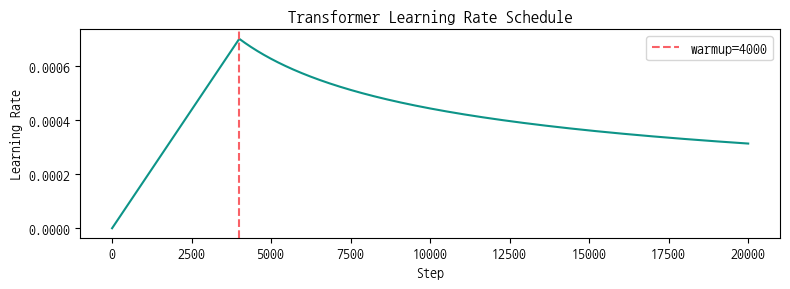

✅ LR Scheduler 정의 완료


In [27]:
# ── 6-2. Learning Rate Scheduler ─────────────────────────────────
# 논문 수식: lr = d_model^(-0.5) × min(step^(-0.5), step × warmup^(-1.5))
# warmup 구간: LR 선형 증가 / 이후: step^(-0.5) 감소

class TransformerScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer    = optimizer
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        self.step_num     = 0

    def step(self):
        self.step_num += 1
        lr = self._get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def _get_lr(self):
        step = self.step_num
        return (self.d_model ** -0.5) * min(
            step ** -0.5,
            step * (self.warmup_steps ** -1.5)
        )

# LR 커브 시각화
steps = list(range(1, 20001))
d_model_check = 512
warmup_check  = 4000

lrs = [(d_model_check ** -0.5) * min(s**-0.5, s*(warmup_check**-1.5)) for s in steps]

plt.figure(figsize=(8, 3))
plt.plot(steps, lrs, color='#0D9488')
plt.axvline(x=warmup_check, color='#F96167', linestyle='--', label=f'warmup={warmup_check}')
plt.xlabel('Step'); plt.ylabel('Learning Rate')
plt.title('Transformer Learning Rate Schedule')
plt.legend(); plt.tight_layout(); plt.show()
print('✅ LR Scheduler 정의 완료')

---

## 🚀 Step 7. 학습하기

### 하이퍼파라미터
| 파라미터 | 값 |
|---|---|
| n_layers | 2 |
| d_model | 512 |
| n_heads | 8 |
| d_ff | 2048 |
| dropout | 0.3 |
| warmup_steps | 4000 |
| batch_size | 64 |
| epochs | 10 |

### 학습 과정
1. DataLoader로 배치 생성
2. Mask 생성 후 모델에 전달
3. Masked Loss로 PAD 제외 학습
4. 매 Epoch마다 예문 번역 출력

In [17]:
# ── 7-1. 하이퍼파라미터 & 모델 선언 ──────────────────────────────
from torch.utils.data import DataLoader, TensorDataset

# 하이퍼파라미터
N_LAYERS    = 2
D_MODEL     = 512
N_HEADS     = 8
D_FF        = 2048
DROPOUT     = 0.3
WARMUP      = 4000
BATCH_SIZE  = 64
EPOCHS      = 10

SRC_VOCAB   = ko_tokenizer.get_piece_size()
TGT_VOCAB   = en_tokenizer.get_piece_size()

# 모델 선언
model = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab=SRC_VOCAB, tgt_vocab=TGT_VOCAB, dropout=DROPOUT, shared=True
).to(DEVICE)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ 모델 파라미터 수: {total_params:,}')

# Optimizer + Scheduler (논문 동일 설정)
optimizer = torch.optim.Adam(
    model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9
)
scheduler = TransformerScheduler(optimizer, D_MODEL, WARMUP)

# DataLoader
dataset    = TensorDataset(enc_train, dec_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

✅ 모델 파라미터 수: 35,214,880


In [18]:
# ── 7-2. Loss 함수 정의 ───────────────────────────────────────────
# PAD 토큰 제외하고 Loss 계산 → 실제 단어 수로 Scaling

def masked_loss(pred, target):
    """PAD(0) 위치를 제외한 Cross-Entropy Loss"""
    # pred:   [batch, tgt_len, tgt_vocab]
    # target: [batch, tgt_len]
    criterion = nn.CrossEntropyLoss(reduction='none')
    loss = criterion(
        pred.contiguous().view(-1, pred.size(-1)),  # [batch*tgt_len, vocab]
        target.contiguous().view(-1)                # [batch*tgt_len]
    )
    mask = (target != 0).float().view(-1)           # PAD=0 제외
    loss = (loss * mask).sum() / mask.sum()         # 유효 토큰 수로 Scaling
    return loss

print('✅ Masked Loss 정의 완료')

✅ Masked Loss 정의 완료


In [19]:
# ── 7-3. 번역 함수 (학습 중 확인용) ──────────────────────────────
def translate(sentence, model, ko_tok, en_tok, max_len=50, plot_attention=False):
    """한국어 문장 → 영어 번역"""
    model.eval()
    with torch.no_grad():
        # 소스 토큰화
        from_sentence = sentence.lower().strip()
        from_sentence = re.sub(r"[^a-z가-힣?.!,\s]+", " ", from_sentence)
        src_tokens    = ko_tok.encode(from_sentence)
        src_tensor    = torch.tensor([src_tokens], dtype=torch.long).to(DEVICE)
        src_mask      = generate_padding_mask(src_tensor).to(DEVICE)

        # 인코더 실행
        src_emb  = model.src_emb(src_tensor) * math.sqrt(D_MODEL)
        src_emb  = model.pos_enc(src_emb)
        enc_out, enc_attns = model.encoder(src_emb, src_mask)

        # 디코더: BOS부터 시작해서 자기회귀 생성
        BOS_ID = en_tok.bos_id()
        EOS_ID = en_tok.eos_id()
        output = [BOS_ID]
        dec_enc_attns_list = []

        for _ in range(max_len):
            tgt_tensor = torch.tensor([output], dtype=torch.long).to(DEVICE)
            tgt_mask   = generate_causality_mask(len(output)).to(DEVICE)

            tgt_emb  = model.tgt_emb(tgt_tensor) * math.sqrt(D_MODEL)
            tgt_emb  = model.pos_enc(tgt_emb)
            dec_out, dec_attns, dec_enc_attns = model.decoder(
                tgt_emb, enc_out, tgt_mask, src_mask
            )
            logits = model.out_linear(dec_out)
            pred   = logits[0, -1].argmax().item()

            if pred == EOS_ID:
                break
            output.append(pred)
            dec_enc_attns_list = dec_enc_attns

        translated = en_tok.decode(output[1:])  # BOS 제외

        # Attention Map 시각화
        if plot_attention and dec_enc_attns_list:
            attn_map = dec_enc_attns_list[-1][0].cpu().numpy()  # 마지막 레이어, head 0
            src_labels = [ko_tok.id_to_piece(t) for t in src_tokens]
            tgt_labels = [en_tok.id_to_piece(t) for t in output[1:]]

            fig, ax = plt.subplots(figsize=(8, 6))
            im = ax.matshow(attn_map[:len(tgt_labels), :len(src_labels)], cmap='Blues')
            ax.set_xticks(range(len(src_labels)))
            ax.set_yticks(range(len(tgt_labels)))
            ax.set_xticklabels(src_labels, rotation=90, fontproperties=font_prop)
            ax.set_yticklabels(tgt_labels)
            ax.set_xlabel('Source (Korean)', fontproperties=font_prop)
            ax.set_ylabel('Target (English)')
            ax.set_title('Cross-Attention Map (마지막 레이어)', fontproperties=font_prop)
            plt.colorbar(im)
            plt.tight_layout()
            plt.show()

        return translated

print('✅ translate 함수 정의 완료')

✅ translate 함수 정의 완료



[Epoch 01/10] Loss: 7.0211 | Time: 188.9s
── Translations ──
  > 오바마는 대통령이다 . → the president s korea is not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not
  > 시민들은 도시 속에 산다 . → the year s new year s year s year s .
  > 커피는 필요 없다 . → the i is not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not not to be to be
  > 일곱 명의 사망자가 발생했다 . → the year s year s year s year s year s .
  💾 최고 모델 저장 (Loss: 7.0211)

[Epoch 02/10] Loss: 5.6597 | Time: 194.2s
── Translations ──
  > 오바마는 대통령이다 . → obama s obama s obama s obama .
  > 시민들은 도시 속에 산다 . → the year old old , the same of the same time .
  > 커피는 필요 없다 . → it is a lot of the same time .
  > 일곱 명의 사망자가 발생했다 . → the incident was killed in the area .
  💾 최고 모델 저장 (Loss: 5.6597)

[Epoch 03/10] Loss: 5.1585 |

  💾 최고 모델 저장 (Loss: 3.8057)


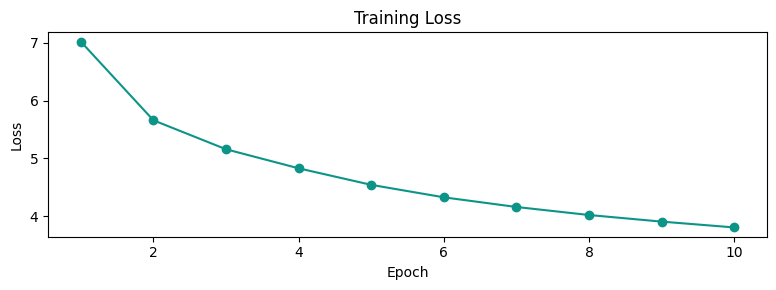

In [20]:
# ── 7-4. 학습 루프 ────────────────────────────────────────────────
# 평가 예문 (루브릭 제시 예문)
TEST_SENTENCES = [
    '오바마는 대통령이다 .',
    '시민들은 도시 속에 산다 .',
    '커피는 필요 없다 .',
    '일곱 명의 사망자가 발생했다 .'
]

best_loss = float('inf')
loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for src_batch, tgt_batch in dataloader:
        src_batch = src_batch.to(DEVICE)
        tgt_batch = tgt_batch.to(DEVICE)

        # 디코더 입력: BOS ~ 마지막-1 / 타겟: 1 ~ EOS
        tgt_input  = tgt_batch[:, :-1]
        tgt_target = tgt_batch[:, 1:]

        # 마스크 생성
        src_mask, tgt_mask = get_masks(src_batch, tgt_input)
        src_mask = src_mask.to(DEVICE)
        tgt_mask = tgt_mask.to(DEVICE)

        # 순전파
        optimizer.zero_grad()
        output, _, _, _ = model(src_batch, tgt_input, src_mask, tgt_mask)

        # Loss 계산 & 역전파
        loss = masked_loss(output, tgt_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        scheduler.step()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    elapsed  = time.time() - start_time

    print(f'\n[Epoch {epoch:02d}/{EPOCHS}] Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s')

    # 매 Epoch 예문 번역
    print('── Translations ──')
    for sent in TEST_SENTENCES:
        result = translate(sent, model, ko_tokenizer, en_tokenizer)
        print(f'  > {sent} → {result}')

    # 최고 모델 저장
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'best_transformer.pt')
        print(f'  💾 최고 모델 저장 (Loss: {best_loss:.4f})')

# Loss 커브 시각화
plt.figure(figsize=(8, 3))
plt.plot(range(1, EPOCHS+1), loss_history, marker='o', color='#0D9488')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training Loss')
plt.tight_layout(); plt.show()

---

## 🌐 Step 8. 최종 번역 & Attention Map 시각화

### 루브릭 제시 예문
1. 오바마는 대통령이다.
2. 시민들은 도시 속에 산다.
3. 커피는 필요 없다.
4. 일곱 명의 사망자가 발생했다.

In [21]:
# ── 최고 모델 로드 ────────────────────────────────────────────────
model.load_state_dict(torch.load('best_transformer.pt', map_location=DEVICE))
model.eval()
print('✅ 최고 모델 로드 완료')

✅ 최고 모델 로드 완료


In [22]:
# ── 최종 번역 결과 출력 ───────────────────────────────────────────
print('='*60)
print('📋 Translations')
print('='*60)
for i, sent in enumerate(TEST_SENTENCES, 1):
    result = translate(sent, model, ko_tokenizer, en_tokenizer)
    print(f'  {i}. {sent}')
    print(f'     → {result}')
    print()

print('='*60)
print('📊 Hyperparameters')
print('='*60)
print(f'  n_layers : {N_LAYERS}')
print(f'  d_model  : {D_MODEL}')
print(f'  n_heads  : {N_HEADS}')
print(f'  d_ff     : {D_FF}')
print(f'  dropout  : {DROPOUT}')
print()
print('='*60)
print('📈 Training Parameters')
print('='*60)
print(f'  Warmup Steps : {WARMUP}')
print(f'  Batch Size   : {BATCH_SIZE}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Best Loss    : {best_loss:.4f}')

📋 Translations
  1. 오바마는 대통령이다 .
     → obama is the president elect .

  2. 시민들은 도시 속에 산다 .
     → many cities are in the city .

  3. 커피는 필요 없다 .
     → the coffee is not a good condition .

  4. 일곱 명의 사망자가 발생했다 .
     → the death toll was reported .

📊 Hyperparameters
  n_layers : 2
  d_model  : 512
  n_heads  : 8
  d_ff     : 2048
  dropout  : 0.3

📈 Training Parameters
  Warmup Steps : 4000
  Batch Size   : 64
  Epochs       : 10
  Best Loss    : 3.8057


In [24]:
# ── translate 함수 수정본 ─────────────────────────────────────────
# 수정 1: attn_map [0] → [0, 0] 으로 head 차원까지 인덱싱
# 수정 2: NanumGothic 폰트 경로 직접 지정

import matplotlib, glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re, math
import torch

# 폰트 재설정
nanum_fonts = glob.glob('/usr/share/fonts/truetype/nanum/NanumGothic*.ttf')
if nanum_fonts:
    font_path = nanum_fonts[0]
    fm.fontManager.addfont(font_path)
    font_prop = fm.FontProperties(fname=font_path)
    matplotlib.rcParams['font.family'] = font_prop.get_name()
else:
    font_prop = fm.FontProperties()
matplotlib.rcParams['axes.unicode_minus'] = False
print('✅ 폰트:', font_prop.get_name())

def translate(sentence, model, ko_tok, en_tok, max_len=50, plot_attention=False):
    model.eval()
    with torch.no_grad():
        sent = sentence.lower().strip()
        sent = re.sub(r"[^a-z가-힣?.!,\s]+", " ", sent)
        src_tokens = ko_tok.encode(sent)
        src_tensor = torch.tensor([src_tokens], dtype=torch.long).to(DEVICE)
        src_mask   = generate_padding_mask(src_tensor).to(DEVICE)

        src_emb = model.src_emb(src_tensor) * math.sqrt(D_MODEL)
        src_emb = model.pos_enc(src_emb)
        enc_out, _ = model.encoder(src_emb, src_mask)

        BOS_ID = en_tok.bos_id()
        EOS_ID = en_tok.eos_id()
        output = [BOS_ID]
        last_dec_enc_attns = None

        for _ in range(max_len):
            tgt_tensor = torch.tensor([output], dtype=torch.long).to(DEVICE)
            tgt_mask   = generate_causality_mask(len(output)).to(DEVICE)
            tgt_emb    = model.tgt_emb(tgt_tensor) * math.sqrt(D_MODEL)
            tgt_emb    = model.pos_enc(tgt_emb)
            dec_out, _, dec_enc_attns = model.decoder(tgt_emb, enc_out, tgt_mask, src_mask)
            logits = model.out_linear(dec_out)
            pred   = logits[0, -1].argmax().item()
            if pred == EOS_ID:
                break
            output.append(pred)
            last_dec_enc_attns = dec_enc_attns

        translated = en_tok.decode(output[1:])

        if plot_attention and last_dec_enc_attns is not None:
            # ✅ 수정: [0] → [0, 0] (배치0, head0 선택)
            attn_map   = last_dec_enc_attns[-1][0, 0].cpu().numpy()
            src_labels = [ko_tok.id_to_piece(t) for t in src_tokens]
            tgt_labels = [en_tok.id_to_piece(t) for t in output[1:]]
            tgt_len, src_len = len(tgt_labels), len(src_labels)

            fig, ax = plt.subplots(figsize=(max(6, src_len), max(5, tgt_len // 2)))
            im = ax.matshow(attn_map[:tgt_len, :src_len], cmap='Blues')
            ax.set_xticks(range(src_len))
            ax.set_yticks(range(tgt_len))
            ax.set_xticklabels(src_labels, rotation=45, ha='left',
                               fontproperties=font_prop, fontsize=11)
            ax.set_yticklabels(tgt_labels, fontsize=11)
            ax.set_xlabel('Source (Korean)', fontproperties=font_prop)
            ax.set_ylabel('Target (English)')
            ax.set_title(f'Cross-Attention Map\n입력: {sentence}',
                         fontproperties=font_prop)
            plt.colorbar(im, ax=ax, shrink=0.8)
            plt.tight_layout()
            plt.show()

        return translated

print('✅ translate 함수 수정 완료')

✅ 폰트: NanumGothicCoding
✅ translate 함수 수정 완료


🗺️ Attention Map 시각화

입력: 오바마는 대통령이다 .


/tmp/ipykernel_695/3961009797.py:75: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


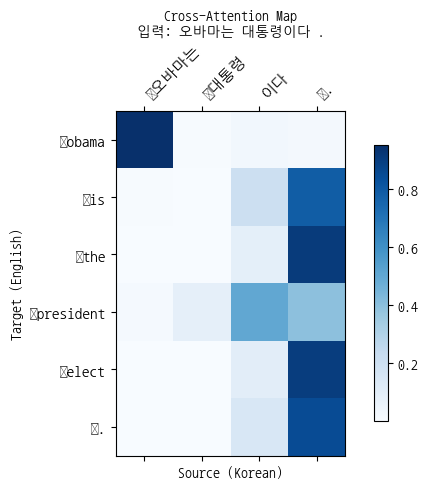

번역: obama is the president elect .

입력: 시민들은 도시 속에 산다 .


/tmp/ipykernel_695/3961009797.py:75: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


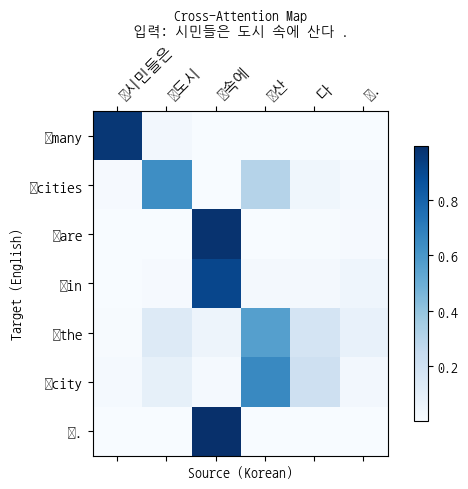

번역: many cities are in the city .

입력: 커피는 필요 없다 .


/tmp/ipykernel_695/3961009797.py:75: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


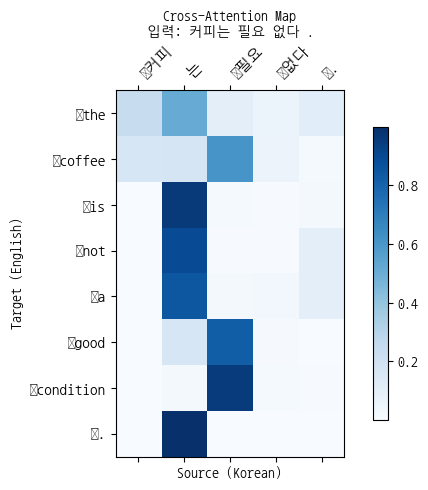

번역: the coffee is not a good condition .

입력: 일곱 명의 사망자가 발생했다 .


/tmp/ipykernel_695/3961009797.py:75: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumGothicCoding.
  fig.canvas.print_figure(bytes_io, **kw)


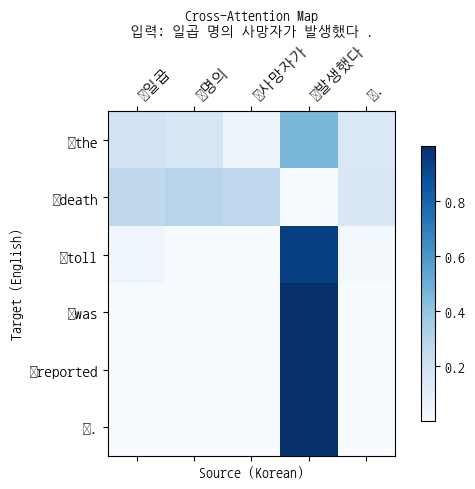

번역: the death toll was reported .


In [25]:
# Attention Map 시각화 셀 다시 실행
print('🗺️ Attention Map 시각화')
for sent in TEST_SENTENCES:
    print(f'\n입력: {sent}')
    result = translate(sent, model, ko_tokenizer, en_tokenizer, plot_attention=True)
    print(f'번역: {result}')

---

## 📝 회고

### 배운 점

- **Transformer 전체 구조**를 처음부터 직접 구현하면서 내부 동작을 깊게 이해했어요.
- **Pre-LN vs Post-LN**: 스택 마지막에 `final_norm`이 없으면 모드 붕괴가 발생하는 이유를 코드로 직접 확인.
- **SentencePiece**: 한/영 각각의 서브워드 토크나이저를 학습시켜 OOV 문제 완화.
- **Masking**: Padding Mask + Causality Mask를 결합하는 방법과 그 이유를 이해.

### 아쉬운 점 / 개선 아이디어

- 학습 데이터가 많지 않아 번역 품질에 한계가 있어요. 더 많은 데이터로 학습하면 개선 가능.
- Beam Search를 적용하면 Greedy Decoding보다 더 좋은 번역 결과를 얻을 수 있을 것 같아요.
- Label Smoothing을 Loss에 적용하면 과적합 방지에 도움이 될 것 같아요.

---

*모두연 엔지니어 3기 · 정슬기 · 2026.07*